# 02 · Normalizing the data: 1NF → 2NF → 3NF

In notebook 01 we found the problems. Here we fix them **one normal form at a time**.
For every step you'll see:

1. **The rule**, in plain English
2. **Where our data breaks it**
3. **The fix**: a new table, built with pandas, so you can *see* it

At the end we check that nothing was lost, and look at the ERD.

| Normal form | The rule in one line |
|---|---|
| **1NF** | Every cell holds **one** value, and there are no repeating columns (`thing_1, thing_2, ...`). |
| **2NF** | 1NF, and every non-key column depends on the **whole** key (only matters when the key has 2+ columns). |
| **3NF** | 2NF, and non-key columns depend **only on the key**, not on another non-key column (no `A → B → C` chains). |

A handy way to remember it: every column must depend on *"the key, the whole key, and nothing but the key."*

In [1]:
import glob, json, re
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)

csv_path = sorted(glob.glob("../Rent_Board_Housing_Inventory_*.csv"))[-1]
raw = pd.read_csv(csv_path, dtype=str)
print(f"Loaded {csv_path}: {raw.shape[0]:,} rows x {raw.shape[1]} columns")

def fd_check(frame, a, b):
    """Does A -> B hold? Returns % of A-values that map to more than one B-value (0% = holds)."""
    sub = frame.dropna(subset=[a, b])
    n = sub.groupby(a)[b].nunique()
    return round((n > 1).mean() * 100, 2)

Loaded ..\Rent_Board_Housing_Inventory_20260830.csv: 549,899 rows x 28 columns


## Step 0 · Starting point: one big flat table

The original file is **one table, 28 columns**, with key `unique_id`.

Before normalizing, we remove the two columns that aren't about housing at all (`data_as_of`, `data_loaded_at`).
They have the same value on every row; they only record when DataSF exported the file.

In [2]:
flat = raw.drop(columns=["data_as_of", "data_loaded_at"]).copy()
print(flat.shape)
flat.head(2).T

(549899, 26)


,0,1
unique_id,2394745219893176429,2578345506591700909
block_num,1804,1234
unit_count,28,18
case_type_name,Housing Inventory - Unit information (2026),Housing Inventory - Unit information (2024)
submission_year,2026,2024
block_address,1300 Block of LA PLAYA ST,1200 Block of HAIGHT ST
occupancy_type,Occupied by non-owner,Occupied by non-owner
occupancy_or_vacancy_date,2022/06/01,2021/04/24
occupancy_or_vacancy_date_year,2022,2021
bedroom_count,One-Bedroom,Two-Bedroom


---
## Step 1 · First Normal Form (1NF)

> **Rule:** every cell holds one atomic value, and there are no repeating groups of columns.

We found three violations in notebook 01.

### 1a. `occupancy_or_vacancy_date_history`: a JSON list inside one cell

(We go straight to a separate table here. Step 2 explains why that's the right move, using utilities as the worked example.)

**Fix:** a child table with **one row per period**. Its key is `(unique_id, seq_no)`,
where `seq_no` numbers the periods within a filing (1, 2, 3...). `unique_id` is also a **foreign key** back to the filing.

In [3]:
h = flat.loc[flat["occupancy_or_vacancy_date_history"].notna(), ["unique_id", "occupancy_or_vacancy_date_history"]]
h = h.assign(entry=h["occupancy_or_vacancy_date_history"].map(json.loads)).explode("entry")
h["seq_no"] = h.groupby("unique_id").cumcount() + 1

occupancy_history = pd.concat(
    [h[["unique_id", "seq_no"]].reset_index(drop=True), pd.json_normalize(h["entry"].tolist())], axis=1
).rename(columns={"date_range_type": "range_type"})
occupancy_history = occupancy_history[["unique_id", "seq_no", "range_type", "start_date", "end_date"]]
for c in ["start_date", "end_date"]:
    occupancy_history[c] = pd.to_datetime(occupancy_history[c], errors="coerce")

print(f"occupancy_history: {len(occupancy_history):,} rows")
occupancy_history.head()

occupancy_history: 80,985 rows


,unique_id,seq_no,range_type,start_date,end_date
0,3448753151243725482,1,Vacant,2022-10-02,NaT
1,3664142395147815712,1,Occupied,2021-06-30,2024-07-21
2,3921341163576885786,1,Vacant,2011-07-05,2023-09-11
3,2391388427570862092,1,Occupied,2016-07-18,2022-07-01
4,2817136686214808630,1,NaN,2019-07-17,2021-06-16


### 1b. The five `base_rent_includes_*` columns: a repeating group

Four columns are Y/N flags for four utilities. The fifth is free text that can mention **several** utilities at once
(`"parking & heat"`, `"cable and internet"`), so that single cell isn't atomic either.

**Fix:** a table with **one row per (filing, included utility)**. We call it a *junction* or *linking* table.
- Checkbox columns: a `Y` becomes a row.
- Free text: we look for keywords (`heat`, `steam` → heat; `wifi`, `cable` → internet, ...). Anything we can't
  recognise becomes `other`, and the original text stays on the filing row so nothing is lost.

In [4]:
CHECKBOX = {
    "base_rent_includes_water_sewer":      "water_sewer",
    "base_rent_includes_natural_gas":      "natural_gas",
    "base_rent_includes_electricity":      "electricity",
    "base_rent_includes_refuse_recycling": "refuse_recycling",
}
KEYWORDS = [  # (regex, utility) checked against the lower-cased free text
    (r"heat|steam|boiler|radiator",          "heat"),
    (r"hot water",                          "hot_water"),
    (r"wifi|wi-fi|internet|cable|broadband", "internet"),
    (r"parking|garage",                     "parking"),
    (r"pest",                               "pest_control"),
    (r"trash|garbage|refuse",               "refuse_recycling"),
    (r"electric",                           "electricity"),
    (r"\bgas\b",                            "natural_gas"),
]
NOT_A_UTILITY = {"no", "n", "none", "non", "n/a", "na", "0", "-", "."}

def utilities_from_text(text):
    t = str(text).strip().lower()
    if t in NOT_A_UTILITY or t == "":
        return []
    found = [u for pattern, u in KEYWORDS if re.search(pattern, t)]
    return sorted(set(found)) or ["other"]

parts = []
for col, util in CHECKBOX.items():
    ids = flat.loc[flat[col] == "Y", "unique_id"]
    parts.append(pd.DataFrame({"unique_id": ids, "utility": util, "source": "checkbox"}))

txt = flat.loc[flat["base_rent_includes_other_utilities"].notna(), ["unique_id", "base_rent_includes_other_utilities"]]
txt = txt.assign(utility=txt["base_rent_includes_other_utilities"].map(utilities_from_text)).explode("utility").dropna(subset=["utility"])
parts.append(txt[["unique_id", "utility"]].assign(source="free_text"))

filing_utility_1nf = pd.concat(parts, ignore_index=True)
# If the same utility was ticked AND written in the text, keep one row but remember both sources.
filing_utility_1nf = (filing_utility_1nf.groupby(["unique_id", "utility"])["source"]
                      .agg(lambda s: "+".join(sorted(set(s)))).reset_index())

print(f"filing_utility: {len(filing_utility_1nf):,} rows")
print(filing_utility_1nf["utility"].value_counts())

filing_utility: 699,175 rows
utility
refuse_recycling    289629
water_sewer         287325
natural_gas          52447
electricity          31468
heat                 22908
other                12045
internet              1523
parking                923
pest_control           700
hot_water              207
Name: count, dtype: int64


### 1c. `point`: two numbers packed into one text value

`"POINT (-122.5094 37.7631)"` holds **longitude and latitude** in one string. Splitting it into two numeric columns makes it atomic.

In [5]:
xy = flat["point"].str.extract(r"POINT \((-?[\d.]+) (-?[\d.]+)\)").astype(float)
flat["longitude"], flat["latitude"] = xy[0], xy[1]
flat[["point", "longitude", "latitude"]].head(3)

,point,longitude,latitude
0,POINT (-122.509404715 37.763084762),-122.509405,37.763085
1,POINT (-122.43292449 37.771847007),-122.432924,37.771847
2,POINT (-122.438217184 37.768080117),-122.438217,37.768080


### After 1NF

The filing table loses the history column and the four checkbox columns. We **keep** the free-text column
(renamed `other_utilities_text`) so the original wording is never lost.

In [6]:
filing_1nf = flat.drop(columns=["occupancy_or_vacancy_date_history", "point", *CHECKBOX.keys()]) \
                 .rename(columns={"base_rent_includes_other_utilities": "other_utilities_text"})
print("filing columns after 1NF:", filing_1nf.shape[1])
print(list(filing_1nf.columns))

filing columns after 1NF: 22
['unique_id', 'block_num', 'unit_count', 'case_type_name', 'submission_year', 'block_address', 'occupancy_type', 'occupancy_or_vacancy_date', 'occupancy_or_vacancy_date_year', 'bedroom_count', 'bathroom_count', 'square_footage', 'monthly_rent', 'other_utilities_text', 'past_occupancy', 'vacancy_date', 'signature_date', 'year_property_built', 'analysis_neighborhood', 'supervisor_district', 'longitude', 'latitude']


---
## Step 2 · Second Normal Form (2NF)

> **Rule:** no column may depend on only **part** of a composite (multi-column) key.

In step 1b we went straight to a separate `filing_utility` table. That skipped a step.
The *textbook* 1NF fix for a repeating group is to turn each (filing, utility) pair into its own row
**and keep all the other columns on it**. Let's build that version, using only real columns, and see why it breaks 2NF.

In [7]:
# The "textbook 1NF" table: one row per (filing, utility), with every other filing column copied onto it.
# (Filings that include no utilities get one row with an empty utility, so no filing is lost.)
wide_1nf = filing_1nf.merge(filing_utility_1nf, on="unique_id", how="left")
print(f"{len(filing_1nf):,} filings became {len(wide_1nf):,} rows")
wide_1nf.loc[wide_1nf["unique_id"].duplicated(keep=False),
             ["unique_id", "utility", "source", "bedroom_count", "monthly_rent", "analysis_neighborhood"]].head(6)

549,899 filings became 942,333 rows


,unique_id,utility,source,bedroom_count,monthly_rent,analysis_neighborhood
1,2578345506591700909,refuse_recycling,checkbox,Two-Bedroom,$2751-$3000,Haight Ashbury
2,2578345506591700909,water_sewer,checkbox,Two-Bedroom,$2751-$3000,Haight Ashbury
5,2835089005575640746,refuse_recycling,checkbox,Studio,$501-$750,Financial District/South Beach
6,2835089005575640746,water_sewer,checkbox,Studio,$501-$750,Financial District/South Beach
10,3207329145732530424,heat,free_text,Studio,$1501-$1750,Financial District/South Beach
11,3207329145732530424,refuse_recycling,checkbox,Studio,$1501-$1750,Financial District/South Beach


**What to notice:** the same filing appears once per utility, with its bedrooms, rent and neighborhood **copied** onto every row.
One filing is no longer one row, so `unique_id` alone isn't a key anymore. The key is now **(`unique_id`, `utility`)**.

Now test which columns depend on the **whole** key and which on only **part** of it:

In [8]:
rows = []
for col in ["bedroom_count", "monthly_rent", "analysis_neighborhood", "signature_date", "source"]:
    rows.append({"column": col,
                 "depends on unique_id alone? (% violations)": fd_check(wide_1nf, "unique_id", col),
                 "depends on utility alone? (% violations)":   fd_check(wide_1nf, "utility", col)})
pd.DataFrame(rows)

,column,depends on unique_id alone? (% violations),depends on utility alone? (% violations)
0,bedroom_count,0.00,100.0
1,monthly_rent,0.00,100.0
2,analysis_neighborhood,0.00,100.0
3,signature_date,0.00,100.0
4,source,11.93,20.0


**How to read this (0% = the dependency holds):**
- `bedroom_count`, `monthly_rent`, `analysis_neighborhood`, `signature_date` (and every other filing column) depend on
  **`unique_id` alone**, which is only *part* of the key. That's a **partial dependency**, so this table **breaks 2NF**.
- `source` (checkbox vs. free text) is the only column that needs **both** parts. Neither `unique_id` nor `utility` alone determines it.

**Why it matters:** a filing's rent is stored once per utility. If one copy were updated and another not, the data would contradict itself
(an **update anomaly**). And a filing with no utilities needs a row with an empty `utility`, which can't be part of a primary key.

**Fix:** split by what each column depends on:
- columns that depend on `unique_id` → `filing` (one row per filing)
- columns that need the whole key → `filing_utility(unique_id, utility_id, source)`
- the list of utility names → `utility(utility_id, name)`, so the junction table stores a small ID instead of repeating text

`occupancy_history` works the same way: packing its periods into the filing table would give a key of (`unique_id`, `seq_no`)
with every filing column depending on `unique_id` alone. That's why it's a separate table.

In [9]:
# The split: filing_1nf (already one row per unique_id) keeps the filing columns; the junction keeps the rest.
assert wide_1nf.drop(columns=["utility", "source"]).drop_duplicates().shape[0] == len(filing_1nf)

utility = pd.DataFrame({"name": sorted(filing_utility_1nf["utility"].unique())})
utility.insert(0, "utility_id", range(1, len(utility) + 1))

filing_utility = (filing_utility_1nf
                  .merge(utility, left_on="utility", right_on="name")
                  [["unique_id", "utility_id", "source"]])
display(utility)
filing_utility.head()

,utility_id,name
0,1,electricity
1,2,heat
2,3,hot_water
3,4,internet
4,5,natural_gas
5,6,other
6,7,parking
7,8,pest_control
8,9,refuse_recycling
9,10,water_sewer


,unique_id,utility_id,source
0,-10000130648883445,9,checkbox
1,-10000130648883445,10,checkbox
2,-1000116357848210128,9,checkbox
3,-1000116357848210128,10,checkbox
4,-1000125088825695476,9,checkbox


**After 2NF:**
- `filing`: key `unique_id`. A one-column key has no "part", so it's automatically 2NF.
- `occupancy_history`: key (`unique_id`, `seq_no`). `range_type`, `start_date`, `end_date` describe that one period, so they need both parts.
- `filing_utility`: key (`unique_id`, `utility_id`). `source` needs both parts.

---
## Step 3 · Third Normal Form (3NF)

> **Rule:** no **transitive** dependencies. A non-key column must not be determined by another non-key column.
> In other words, no chain like `unique_id → A → B`. If `A → B`, then `B` belongs in a table keyed by `A`.

Let's test the chains we suspected in notebook 01. **0% = the dependency holds**, so it's a 3NF problem to fix.

In [10]:
f = filing_1nf.assign(point_text=flat["point"])
candidates = [
    ("submission_year",  "case_type_name"),
    ("point_text",       "analysis_neighborhood"),
    ("point_text",       "supervisor_district"),
    ("point_text",       "longitude"),
]
rows = [{"A (non-key)": a, "B (non-key)": b, "% violations": fd_check(f, a, b)} for a, b in candidates]

# occupancy date -> occupancy year: does the year column just repeat the date's year?
d = pd.to_datetime(f["occupancy_or_vacancy_date"], format="%Y/%m/%d", errors="coerce")
yr = pd.to_numeric(f["occupancy_or_vacancy_date_year"], errors="coerce")
both = d.notna() & yr.notna()
rows.append({"A (non-key)": "occupancy_or_vacancy_date", "B (non-key)": "occupancy_or_vacancy_date_year",
             "% violations": round((d[both].dt.year != yr[both]).mean() * 100, 2)})
# and the ones that should NOT hold
for a, b in [("block_address", "year_property_built"), ("block_address", "unit_count"),
             ("analysis_neighborhood", "supervisor_district")]:
    rows.append({"A (non-key)": a, "B (non-key)": b, "% violations": fd_check(f, a, b)})
pd.DataFrame(rows)

,A (non-key),B (non-key),% violations
0,submission_year,case_type_name,0.00
1,point_text,analysis_neighborhood,0.00
2,point_text,supervisor_district,0.00
3,point_text,longitude,0.00
4,occupancy_or_vacancy_date,occupancy_or_vacancy_date_year,0.00
5,block_address,year_property_built,71.48
6,block_address,unit_count,70.02
7,analysis_neighborhood,supervisor_district,58.54


**What this tells us:**

| Chain found | 3NF fix |
|---|---|
| `unique_id → submission_year → case_type_name` | `filing_year(submission_year PK, case_type_name)` |
| `unique_id → point → neighborhood, district, lon, lat` | `location_point(point_id PK, longitude, latitude, neighborhood_id FK, supervisor_district)` |
| `unique_id → occupancy date → occupancy year` | keep the year **only when there is no full date** (otherwise it's a copy of the date's year) |
| `unique_id → raw label → cleaned value` (bedrooms, bathrooms, rent, sq ft) | one lookup table each: raw label + cleaned numbers |

The last three rows (**not** 0%) confirm what we *can't* do: block → building facts don't hold, and neighborhoods cross district lines.
So `year_property_built` and `unit_count` stay on each filing row.

### 3a. `filing_year`

In [11]:
filing_year = (filing_1nf[["submission_year", "case_type_name"]].drop_duplicates()
               .astype({"submission_year": int}).sort_values("submission_year").reset_index(drop=True))
filing_year

,submission_year,case_type_name
0,2022,Housing Inventory - Unit information (2022)
1,2023,Housing Inventory - Unit information (2023)
2,2024,Housing Inventory - Unit information (2024)
3,2025,Housing Inventory - Unit information (2025)
4,2026,Housing Inventory - Unit information (2026)


### 3b. `neighborhood` and `location_point`

A **surrogate key** is a made-up ID number (`point_id = 1, 2, 3...`). We use one because the raw point text is long and clumsy as a key.

In [12]:
neighborhood = (pd.DataFrame({"name": sorted(filing_1nf["analysis_neighborhood"].dropna().unique())}))
neighborhood.insert(0, "neighborhood_id", range(1, len(neighborhood) + 1))

lp = (f[["point_text", "longitude", "latitude", "analysis_neighborhood", "supervisor_district"]]
      .dropna(subset=["point_text"]).drop_duplicates("point_text").reset_index(drop=True))
lp.insert(0, "point_id", range(1, len(lp) + 1))
lp = lp.merge(neighborhood, left_on="analysis_neighborhood", right_on="name", how="left")
location_point = lp[["point_id", "longitude", "latitude", "neighborhood_id", "supervisor_district"]].copy()
location_point["neighborhood_id"] = location_point["neighborhood_id"].astype("Int64")
location_point["supervisor_district"] = pd.to_numeric(location_point["supervisor_district"]).astype("Int64")
point_key = lp[["point_text", "point_id"]]   # used below to swap point text for point_id on each filing

print(f"neighborhood: {len(neighborhood)} rows | location_point: {len(location_point):,} rows")
location_point.head()

neighborhood: 41 rows | location_point: 13,368 rows


,point_id,longitude,latitude,neighborhood_id,supervisor_district
0,1,-122.509405,37.763085,35,4
1,2,-122.432924,37.771847,9,5
2,3,-122.438217,37.768080,3,8
3,4,-122.370477,37.728346,1,10
4,5,-122.406342,37.785982,6,3


### 3c. Lookup tables for the messy categories (this is also where the **cleaning** happens)

Each lookup table keeps the **raw label exactly as typed** (so we can always trace back) plus the **cleaned value**.
The functions below turn 45 bedroom spellings into a number. Labels we can't interpret honestly (`Garage`, `$D$61`, `2A`) get `NULL` + `is_unparseable = True`.
We never guess.

In [13]:
WORDS = {"one": 1, "two": 2, "three": 3, "four": 4, "five": 5}

def parse_bedrooms(label):
    s = label.strip().lower()
    if "studio" in s or s.startswith("zero"):
        return 0
    if s == "5+":
        return 5                      # "5 or more"
    m = re.match(r"^(one|two|three|four|five)[\s-]*bedroom$", s)
    if m:
        return WORDS[m.group(1)]
    m = re.match(r"^(\d)\s*(b\w*)?$", s)   # 1, 2br, 3 bedroom, 2 bedriin (typo), 1 bed
    if m:
        return int(m.group(1))
    return None                       # Garage, Vacant, $D$61, 2A, 1U ...

def make_lookup(series, id_name, parser, value_cols):
    labels = pd.Series(sorted(series.dropna().unique()), name="raw_label")
    parsed = pd.DataFrame([parser(x) for x in labels], columns=value_cols)
    out = pd.concat([labels, parsed], axis=1)
    out.insert(0, id_name, range(1, len(out) + 1))
    return out

bedroom_type = make_lookup(filing_1nf["bedroom_count"], "bedroom_type_id",
                           lambda x: (parse_bedrooms(x),), ["bedrooms"])
bedroom_type["bedrooms"] = bedroom_type["bedrooms"].astype("Int64")
bedroom_type["is_unparseable"] = bedroom_type["bedrooms"].isna()
bedroom_type

,bedroom_type_id,raw_label,bedrooms,is_unparseable
0,1,$D$61,<NA>,True
1,2,0,0,False
2,3,0A,<NA>,True
3,4,0AH,<NA>,True
4,5,0U,<NA>,True
5,6,1,1,False
6,7,1 Bedroom,1,False
7,8,1 bed,1,False
8,9,1 bedroom,1,False
9,10,1A,<NA>,True


In [14]:
def parse_bathrooms(label):
    s = " ".join(label.strip().lower().split())
    if "bed" in s:
        return (None, False)          # bedroom text typed in the bathroom box
    if s.startswith("shared"):
        return (None, True)           # a real category (shared/SRO), not a number
    for words, n in [("one and a half", 1.5), ("two and a half", 2.5), ("three", 3.0), ("one", 1.0), ("two", 2.0)]:
        if s.startswith(words):
            return (n, False)
    m = re.match(r"^(\d+(\.\d+)?)\s*(b\w*)?$", s)
    if m:
        return (float(m.group(1)), False)
    return (None, False)              # E3 ...

bathroom_type = make_lookup(filing_1nf["bathroom_count"], "bathroom_type_id", parse_bathrooms, ["bathrooms", "is_shared"])
bathroom_type["is_unparseable"] = bathroom_type["bathrooms"].isna() & ~bathroom_type["is_shared"]
bathroom_type

,bathroom_type_id,raw_label,bathrooms,is_shared,is_unparseable
0,1,0,0.0,False,False
1,2,1,1.0,False,False
2,3,1 bathroom,1.0,False,False
3,4,1 bedroom,NaN,False,True
4,5,1.00,1.0,False,False
5,6,1bathroom,1.0,False,False
6,7,2,2.0,False,False
7,8,2 bathroom,2.0,False,False
8,9,2 bathroom,2.0,False,False
9,10,2 batroom,2.0,False,False


In [15]:
def parse_rent(label):
    s = label.strip()
    if s.startswith("$0") or s == "0":
        return (None, None, True)                 # "no rent paid", not a rent of $0
    m = re.match(r"^\$(\d+)-\$(\d+)$", s)
    if m:
        return (int(m.group(1)), int(m.group(2)), False)
    m = re.match(r"^\$(\d+)\+$", s)
    if m:
        return (int(m.group(1)), None, False)     # "$7000+" has no upper limit
    return (None, None, False)

rent_band = make_lookup(filing_1nf["monthly_rent"], "rent_band_id", parse_rent, ["rent_min", "rent_max", "is_no_rent_paid"])
rent_band[["rent_min", "rent_max"]] = rent_band[["rent_min", "rent_max"]].astype("Int64")

def parse_sqft(label):
    s = label.strip().lower()
    if s == "unknown":
        return (None, None, True)
    m = re.match(r"^(\d+)-(\d+) sq\.ft$", s)
    if m:
        return (int(m.group(1)), int(m.group(2)), False)
    m = re.match(r"^(\d+)\+ sq\.ft$", s)
    if m:
        return (int(m.group(1)), None, False)
    return (None, None, False)

sqft_band = make_lookup(filing_1nf["square_footage"], "sqft_band_id", parse_sqft, ["sqft_min", "sqft_max", "is_unknown"])
sqft_band[["sqft_min", "sqft_max"]] = sqft_band[["sqft_min", "sqft_max"]].astype("Int64")

occupancy_type = pd.DataFrame({"name": sorted(filing_1nf["occupancy_type"].unique())})
occupancy_type.insert(0, "occupancy_type_id", range(1, len(occupancy_type) + 1))

rent_band.sort_values("rent_min").head(8)

,rent_band_id,raw_label,rent_min,rent_max,is_no_rent_paid
1,2,$1-$250,1,250,False
9,10,$250-$500,250,500,False
11,12,$251-$500,251,500,False
22,23,$501-$750,501,750,False
31,32,$751-$1000,751,1000,False
2,3,$1001-$1250,1001,1250,False
3,4,$1251-$1500,1251,1500,False
4,5,$1501-$1750,1501,1750,False


> 💡 **Is a lookup table like `occupancy_type` required by 3NF?** Strictly, no. A column holding the text `"Vacant"` doesn't depend on another column.
> We add it anyway for **consistency** (only 4 allowed values, enforced by a foreign key) and smaller storage.
> The bedroom/bathroom/rent/sqft tables *are* 3NF fixes, because once we add cleaned values, `raw label → cleaned value` is a real dependency.

### 3d. Cleaning the date columns

Rule: a date outside a believable window becomes `NULL` (empty). Everything else is kept as is.

- `signature_date` must be 2022 to 2026 (the reporting program started in 2022)
- occupancy and vacancy dates must be 1900 to 2026

For the occupancy **year**: keep it only when there's no full date (to fix the 3NF chain above), and move the
`"Year Unknown (...)"` answers into their own column instead of mixing text with numbers.

In [16]:
def clean_date(s, lo, hi):
    d = pd.to_datetime(s, format="%Y/%m/%d", errors="coerce")
    return d.where((d.dt.year >= lo) & (d.dt.year <= hi))

sig = clean_date(filing_1nf["signature_date"], 2022, 2026)
occ = clean_date(filing_1nf["occupancy_or_vacancy_date"], 1900, 2026)
vac = clean_date(filing_1nf["vacancy_date"], 1900, 2026)

yr_text = filing_1nf["occupancy_or_vacancy_date_year"]
yr_num = pd.to_numeric(yr_text, errors="coerce")
yr_valid = yr_num.where((yr_num >= 1900) & (yr_num <= 2026))
occupancy_year_only = yr_valid.where(occ.isna()).astype("Int64")          # only when there's no full date
occupancy_year_unknown = yr_text.where(yr_text.fillna("").str.lower().str.startswith("year"))

report = pd.DataFrame({
    "column": ["signature_date", "occupancy_or_vacancy_date", "vacancy_date", "occupancy year (numeric)"],
    "had a value": [filing_1nf["signature_date"].notna().sum(), filing_1nf["occupancy_or_vacancy_date"].notna().sum(),
                    filing_1nf["vacancy_date"].notna().sum(), yr_num.notna().sum()],
    "set to NULL (invalid)": [filing_1nf["signature_date"].notna().sum() - sig.notna().sum(),
                              filing_1nf["occupancy_or_vacancy_date"].notna().sum() - occ.notna().sum(),
                              filing_1nf["vacancy_date"].notna().sum() - vac.notna().sum(),
                              yr_num.notna().sum() - yr_valid.notna().sum()],
})
report

,column,had a value,set to NULL (invalid)
0,signature_date,549899,136
1,occupancy_or_vacancy_date,446867,147
2,vacancy_date,21179,88
3,occupancy year (numeric),470705,183


### 3e. Build the final `filing` table

Every messy text column is swapped for a **foreign key** (an ID pointing into a lookup table).

In [17]:
def fk(series, lookup, id_col, label_col="raw_label"):
    return series.map(dict(zip(lookup[label_col], lookup[id_col]))).astype("Int64")

filing = pd.DataFrame({
    "unique_id":                filing_1nf["unique_id"],
    "submission_year":          filing_1nf["submission_year"].astype(int),
    "signature_date":           sig,
    "block_num":                filing_1nf["block_num"],
    "block_address":            filing_1nf["block_address"],
    "point_id":                 flat["point"].map(dict(zip(point_key["point_text"], point_key["point_id"]))).astype("Int64"),
    "unit_count":               pd.to_numeric(filing_1nf["unit_count"], errors="coerce").round().astype("Int64"),
    "year_property_built":      pd.to_numeric(filing_1nf["year_property_built"], errors="coerce").astype("Int64"),
    "occupancy_type_id":        fk(filing_1nf["occupancy_type"], occupancy_type, "occupancy_type_id", "name"),
    "bedroom_type_id":          fk(filing_1nf["bedroom_count"], bedroom_type, "bedroom_type_id"),
    "bathroom_type_id":         fk(filing_1nf["bathroom_count"], bathroom_type, "bathroom_type_id"),
    "sqft_band_id":             fk(filing_1nf["square_footage"], sqft_band, "sqft_band_id"),
    "rent_band_id":             fk(filing_1nf["monthly_rent"], rent_band, "rent_band_id"),
    "occupancy_date":           occ,
    "occupancy_year_only":      occupancy_year_only,
    "occupancy_year_unknown":   occupancy_year_unknown,
    "vacancy_date":             vac,
    "past_occupancy":           filing_1nf["past_occupancy"].map({"Yes": True, "No": False}).astype("boolean"),
    "other_utilities_text":     filing_1nf["other_utilities_text"],
})
print(filing.shape)
filing.head(3).T

(549899, 19)


,0,1,2
unique_id,2394745219893176429,2578345506591700909,2727111245427804121
submission_year,2026,2024,2023
signature_date,2025-11-26 00:00:00,2024-02-13 00:00:00,2023-01-13 00:00:00
block_num,1804,1234,2616
block_address,1300 Block of LA PLAYA ST,1200 Block of HAIGHT ST,500 Block of BUENA VISTA AVE
point_id,1,2,3
unit_count,28,18,41
year_property_built,1958,1906,1929
occupancy_type_id,2,2,2
bedroom_type_id,34,40,40


---
## Step 4 · The final schema

| # | Table | Primary key | Foreign keys | What one row is |
|---|---|---|---|---|
| 1 | `filing` | `unique_id` | `submission_year`, `point_id`, `occupancy_type_id`, `bedroom_type_id`, `bathroom_type_id`, `sqft_band_id`, `rent_band_id` | one owner's yearly report about one unit |
| 2 | `occupancy_history` | (`unique_id`, `seq_no`) | `unique_id → filing` | one occupied/vacant period |
| 3 | `filing_utility` | (`unique_id`, `utility_id`) | `unique_id → filing`, `utility_id → utility` | "this filing's rent includes this utility" |
| 4 | `utility` | `utility_id` | | one kind of utility |
| 5 | `filing_year` | `submission_year` | | one reporting year |
| 6 | `location_point` | `point_id` | `neighborhood_id → neighborhood` | one block mid-point on the map |
| 7 | `neighborhood` | `neighborhood_id` | | one SF analysis neighborhood |
| 8 | `occupancy_type` | `occupancy_type_id` | | tenant / owner / vacant / non-residential |
| 9 | `bedroom_type` | `bedroom_type_id` | | one raw bedroom label + cleaned count |
| 10 | `bathroom_type` | `bathroom_type_id` | | one raw bathroom label + cleaned count |
| 11 | `rent_band` | `rent_band_id` | | one $250 rent range |
| 12 | `sqft_band` | `sqft_band_id` | | one 250 sq-ft range |

In [18]:
tables = {
    "filing": filing, "occupancy_history": occupancy_history, "filing_utility": filing_utility, "utility": utility,
    "filing_year": filing_year, "location_point": location_point, "neighborhood": neighborhood,
    "occupancy_type": occupancy_type, "bedroom_type": bedroom_type, "bathroom_type": bathroom_type,
    "rent_band": rent_band, "sqft_band": sqft_band,
}
counts = pd.DataFrame({"rows": {k: len(v) for k, v in tables.items()},
                       "columns": {k: v.shape[1] for k, v in tables.items()}})
print(f"{len(tables)} tables, {counts['rows'].sum():,} rows in total")
counts

12 tables, 1,343,614 rows in total


,rows,columns
filing,549899,19
occupancy_history,80985,5
filing_utility,699175,3
utility,10,2
filing_year,5,2
location_point,13368,5
neighborhood,41,2
occupancy_type,4,2
bedroom_type,45,4
bathroom_type,30,5


### Integrity checks

1. **Primary keys are unique**
2. **Every foreign key points at a row that exists** (no "orphans")
3. **Lossless:** joining the tables back together gives the original values

In [19]:
pks = {"filing": ["unique_id"], "occupancy_history": ["unique_id", "seq_no"], "filing_utility": ["unique_id", "utility_id"],
       "utility": ["utility_id"], "filing_year": ["submission_year"], "location_point": ["point_id"],
       "neighborhood": ["neighborhood_id"], "occupancy_type": ["occupancy_type_id"], "bedroom_type": ["bedroom_type_id"],
       "bathroom_type": ["bathroom_type_id"], "rent_band": ["rent_band_id"], "sqft_band": ["sqft_band_id"]}
for t, cols in pks.items():
    assert not tables[t].duplicated(cols).any(), t
print("1. all primary keys unique ✔")

fks = [("filing", "submission_year", "filing_year", "submission_year"), ("filing", "point_id", "location_point", "point_id"),
       ("filing", "occupancy_type_id", "occupancy_type", "occupancy_type_id"), ("filing", "bedroom_type_id", "bedroom_type", "bedroom_type_id"),
       ("filing", "bathroom_type_id", "bathroom_type", "bathroom_type_id"), ("filing", "sqft_band_id", "sqft_band", "sqft_band_id"),
       ("filing", "rent_band_id", "rent_band", "rent_band_id"), ("occupancy_history", "unique_id", "filing", "unique_id"),
       ("filing_utility", "unique_id", "filing", "unique_id"), ("filing_utility", "utility_id", "utility", "utility_id"),
       ("location_point", "neighborhood_id", "neighborhood", "neighborhood_id")]
for child, col, parent, pcol in fks:
    vals = tables[child][col].dropna()
    orphans = (~vals.isin(tables[parent][pcol])).sum()
    assert orphans == 0, (child, col, orphans)
print("2. no orphan foreign keys ✔")

1. all primary keys unique ✔
2. no orphan foreign keys ✔


In [20]:
# 3. Lossless: rebuild some original columns by JOINing, and compare with the raw file
rebuilt = (filing[["unique_id", "submission_year", "point_id", "bedroom_type_id", "rent_band_id"]]
    .merge(filing_year, on="submission_year", how="left")
    .merge(bedroom_type[["bedroom_type_id", "raw_label"]].rename(columns={"raw_label": "bedroom_count"}), on="bedroom_type_id", how="left")
    .merge(rent_band[["rent_band_id", "raw_label"]].rename(columns={"raw_label": "monthly_rent"}), on="rent_band_id", how="left")
    .merge(location_point, on="point_id", how="left")
    .merge(neighborhood.rename(columns={"name": "analysis_neighborhood"}), on="neighborhood_id", how="left"))
rebuilt = rebuilt.set_index("unique_id").loc[raw["unique_id"]]

def same(a, b):
    return ((a.values == b.values) | (pd.isna(a.values) & pd.isna(b.values))).all()

for col in ["case_type_name", "bedroom_count", "monthly_rent", "analysis_neighborhood"]:
    print(f"{col:24s} identical to original: {same(rebuilt[col].astype(object), raw[col].astype(object))}")
print(f"{'supervisor_district':24s} identical to original: "
      f"{same(rebuilt['supervisor_district'].astype('string'), raw['supervisor_district'].astype('string'))}")

# the four Y/N utility flags
for col, util in CHECKBOX.items():
    uid = utility.loc[utility["name"] == util, "utility_id"].item()
    has = set(filing_utility.loc[(filing_utility["utility_id"] == uid) & filing_utility["source"].str.contains("checkbox"), "unique_id"])
    rebuilt_flag = raw["unique_id"].map(lambda i: "Y" if i in has else "N")
    print(f"{col:38s} identical to original: {(rebuilt_flag == raw[col]).all()}")

case_type_name           identical to original: True
bedroom_count            identical to original: True
monthly_rent             identical to original: True
analysis_neighborhood    identical to original: True
supervisor_district      identical to original: True
base_rent_includes_water_sewer         identical to original: True
base_rent_includes_natural_gas         identical to original: True
base_rent_includes_electricity         identical to original: True
base_rent_includes_refuse_recycling    identical to original: True


---
## Step 5 · The ERD

`keerat_erd.png` (in this folder) draws the 12 tables. How to read it:

- Each box is a table. **PK** = primary key, **FK** = foreign key.
- A line joins a foreign key to the table it points at.
- **1 — N** means *one* row on the "1" side relates to *many* rows on the "N" side.
  For example, one `rent_band` is used by many filings, but each filing has one rent band.
- `filing_utility` sits between `filing` and `utility` because that relationship is **many-to-many**:
  a filing can include many utilities, and a utility is included in many filings.

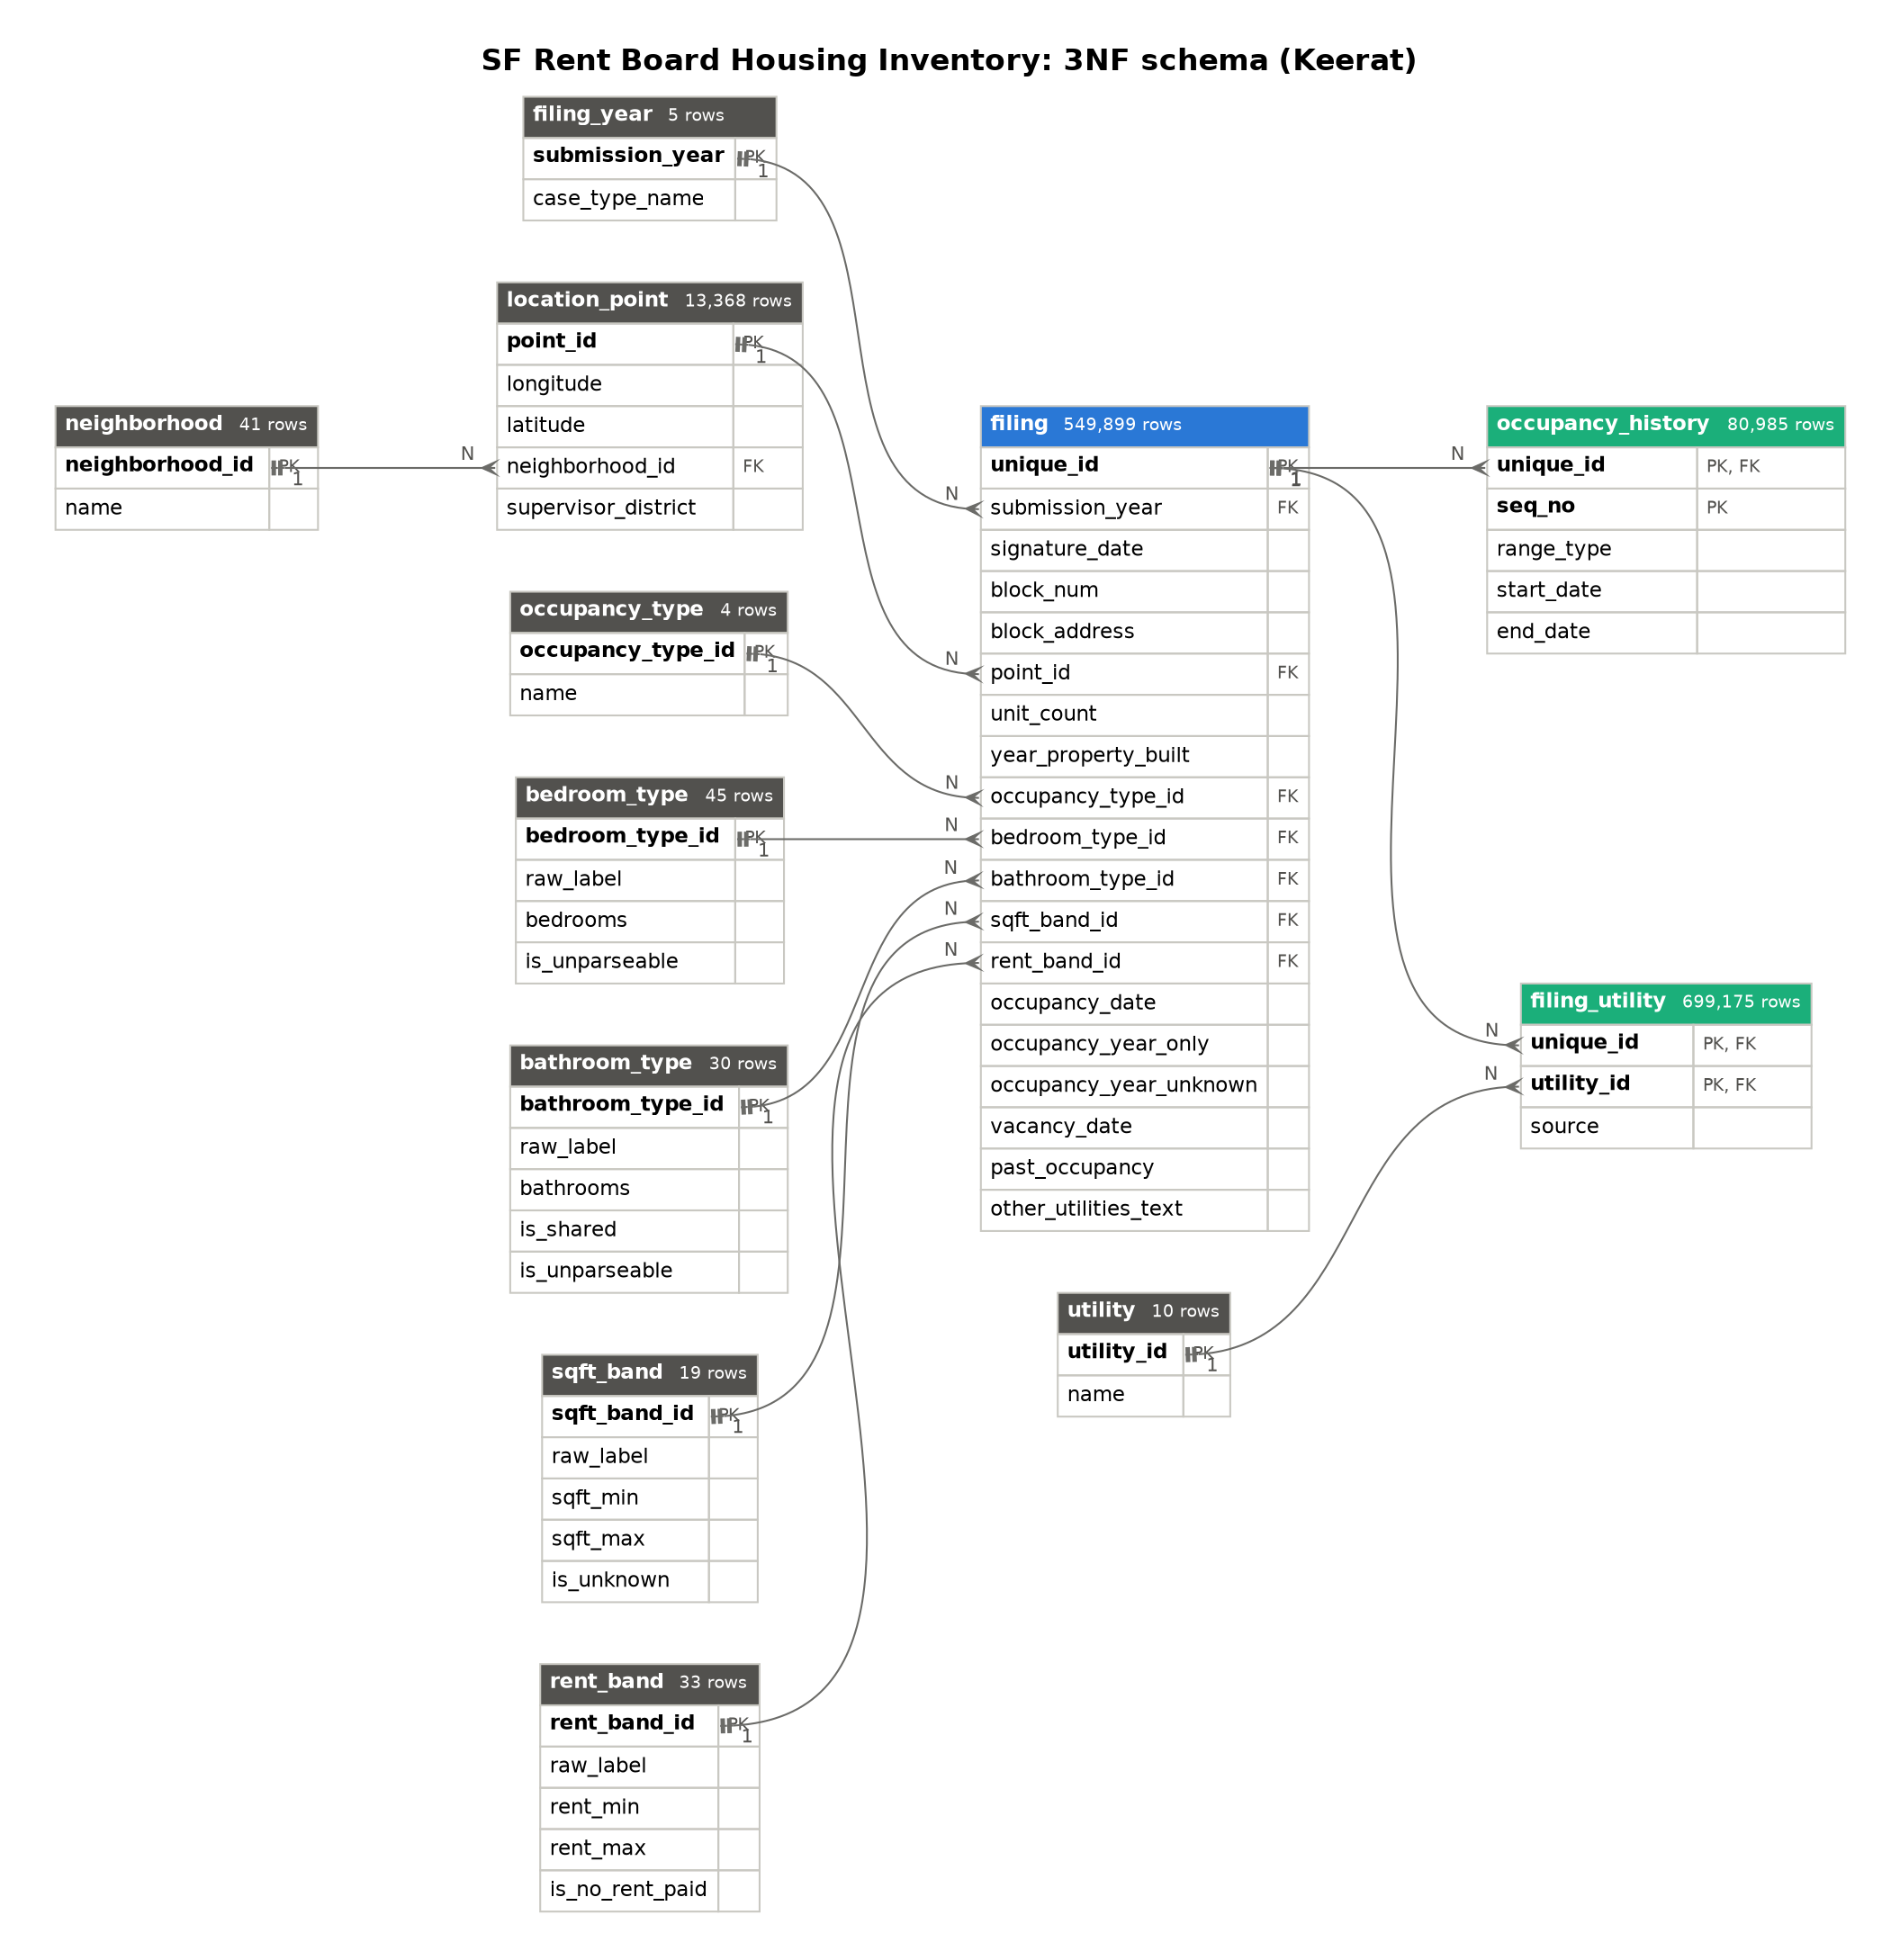

In [21]:
from IPython.display import Image
Image("keerat_erd.png")

---
## Step 6 · Save the tables (for loading into MySQL later)

This writes one CSV per table into `DATA_201/keerat_tables/`. **Don't upload these to GitHub** (too big).
They're for the MySQL step after Wednesday.

In [22]:
import os
out = "../keerat_tables"
os.makedirs(out, exist_ok=True)
for name, t in tables.items():
    t.to_csv(f"{out}/{name}.csv", index=False)
print("saved:", sorted(os.listdir(out)))

saved: ['bathroom_type.csv', 'bedroom_type.csv', 'filing.csv', 'filing_utility.csv', 'filing_year.csv', 'location_point.csv', 'neighborhood.csv', 'occupancy_history.csv', 'occupancy_type.csv', 'rent_band.csv', 'sqft_band.csv', 'utility.csv']


---
## Summary: what to say in the presentation

1. **1NF:** the history JSON became `occupancy_history`. The five utility columns became `utility` + `filing_utility`. `point` was split into longitude/latitude.
2. **2NF:** the textbook 1NF table (one row per filing × utility, key `(unique_id, utility)`) had a partial dependency: every filing column depended on `unique_id` alone. Splitting it gives `filing`, `filing_utility` and `utility`.
3. **3NF:** we removed four kinds of chains: year → case type, point → neighborhood/district, raw label → cleaned value, and date → year.
4. **What we deliberately did *not* do:** no building/property table, because block-level facts are inconsistent (~70% conflicts).
5. **Checks:** unique PKs, no orphan FKs, and joining back reproduces the original values.